# 08 — Analyse d'Équité Algorithmique (Fairness)

## Pourquoi cette analyse est l'originalité du projet

La plupart des projets ML sur BAF traitent le dataset comme un simple problème de classification.
**L'angle fairness est ce qui distingue notre projet** — et c'est exactement ce que les régulateurs
(AI Act européen 2024, RGPD Article 22) commencent à imposer aux institutions bancaires.

## Cadre réglementaire

| Texte | Exigence |
|-------|----------|
| **RGPD Article 22** | Droit à l'explication des décisions automatisées |
| **AI Act (UE)** | Évaluation obligatoire des biais sur les attributs protégés |
| **Règle des 4/5 (US)** | Disparate Impact Ratio < 0.8 = discrimination significative |

## Question de recherche

> **Le modèle XGBoost flague-t-il équitablement les différents groupes (âge, revenu, statut
> professionnel) ? Si non, quelle correction peut-on appliquer et à quel coût ?**

## Critères d'équité mesurés

| Critère | Définition | Pertinent pour la fraude |
|---------|------------|--------------------------|
| **Equal Opportunity** | Recall équivalent entre groupes | ★★★ Oui |
| **Equal FPR** | Taux de fausses alertes équivalent entre groupes | ★★★ Oui — critère principal |
| **Demographic Parity** | Taux d'alertes égal entre groupes | ★ Peu pertinent en fraude |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.fairness import (
    compute_group_metrics, disparate_impact_ratio, fairness_summary
)
from src.visualization import plot_fairness_metrics
from src.evaluation import find_optimal_threshold

# Chargement
X_test = pd.read_parquet('../data/parquets/X_test.parquet')
y_test = pd.read_parquet('../data/parquets/y_test.parquet')['fraud_bool']

# Modèle LightGBM (le plus performant individuellement)
lightgbm_model = joblib.load('../results/lightgbm_model.pkl')

# Prédictions
y_score = lightgbm_model.predict_proba(X_test)[:, 1]
threshold = find_optimal_threshold(y_test.values, y_score, criterion='f1')
y_pred = (y_score >= threshold).astype(int)

print(f"Seuil de décision optimal (F1) : {threshold:.3f}")
print(f"Taux d'alertes global : {y_pred.mean():.2%}")

Seuil de décision optimal (F1) : 0.893
Taux d'alertes global : 1.81%


## 1. Analyse par tranche d'âge

In [2]:
age_metrics = compute_group_metrics(
    y_test.values, y_pred, X_test['customer_age'].values, 'age'
)
age_metrics = disparate_impact_ratio(age_metrics, metric='fpr')
age_metrics

,age,n,fraud_rate,positive_rate,fpr,fnr,recall,precision,disparate_impact_ratio
0,10,5096,0.004317,0.000589,0.000394,0.954545,0.045455,0.333333,0.003153
1,20,46341,0.006668,0.004467,0.003519,0.854369,0.145631,0.217391,0.028154
2,30,63322,0.011276,0.011513,0.009232,0.788515,0.211485,0.207133,0.073856
3,40,56473,0.014945,0.020488,0.016358,0.707346,0.292654,0.213483,0.130867
4,50,25676,0.024537,0.041556,0.032939,0.615873,0.384127,0.226804,0.263515
5,60,6464,0.042853,0.067760,0.049459,0.523466,0.476534,0.301370,0.395668
6,70,1339,0.050784,0.064974,0.047207,0.602941,0.397059,0.310345,0.377655
7,80,284,0.049296,0.098592,0.074074,0.428571,0.571429,0.285714,0.592593
8,90,16,0.000000,0.125000,0.125000,0.000000,0.000000,0.000000,1.000000


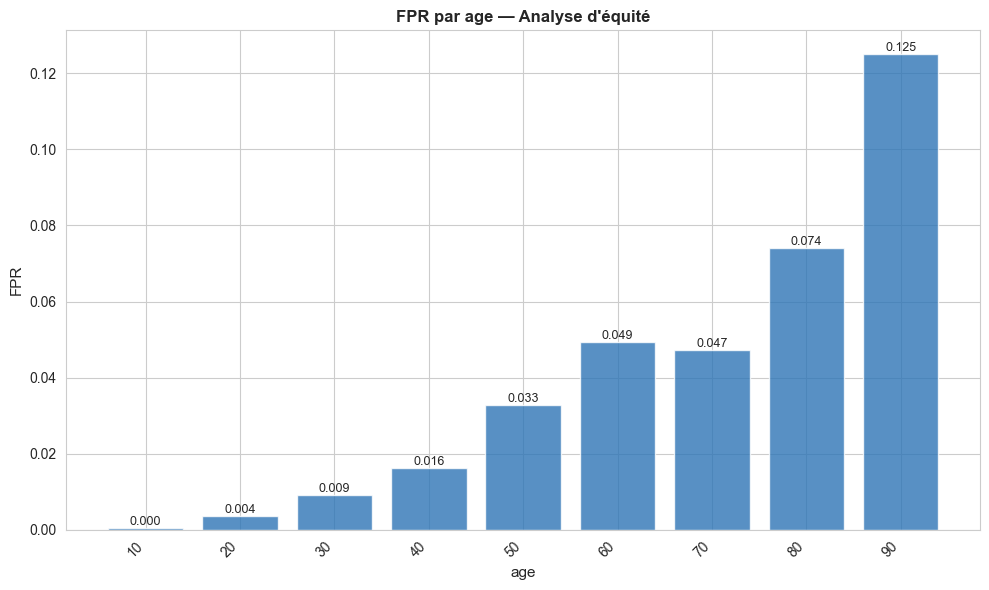

In [3]:
# Visualisation du FPR par âge
plot_fairness_metrics(age_metrics, 'age', metric='fpr',
                       save_path='../reports/figures/23_fpr_by_age.png')

**Interprétation critique :**

Si le FPR est **significativement plus élevé pour les tranches d'âge élevées**, cela signifie
que le modèle **génère plus de fausses alertes pour les personnes âgées**.

**Impact opérationnel :** un client âgé légitime a plus de chances d'être à tort suspecté de
fraude — friction client, perte de confiance, risque réputationnel.

**Origine du biais :** il vient des **données d'entraînement** elles-mêmes. Nous avons vu en EDA
que le taux de fraude augmente avec l'âge (personnes plus ciblées par usurpation d'identité).
Le modèle apprend cette corrélation et la sur-applique.

## 2. Analyse par niveau de revenu

In [4]:
# income est déjà discrétisée dans BAF (valeurs 0.1, 0.2, ..., 0.9)
income_metrics = compute_group_metrics(
    y_test.values, y_pred,
    X_test['income'].values,  # directement, pas de qcut
    'income_level'
)
income_metrics = disparate_impact_ratio(income_metrics, metric='fpr')
income_metrics

,income_level,n,fraud_rate,positive_rate,fpr,fnr,recall,precision,disparate_impact_ratio
0,0.1,22600,0.007124,0.004292,0.003432,0.875776,0.124224,0.206186,0.122438
1,0.2,11277,0.006828,0.004700,0.003393,0.805195,0.194805,0.283019,0.121059
2,0.3,8528,0.008326,0.007739,0.005558,0.732394,0.267606,0.287879,0.198295
3,0.4,14562,0.009339,0.008035,0.006100,0.786765,0.213235,0.247863,0.217654
4,0.5,10254,0.009167,0.009265,0.008071,0.861702,0.138298,0.136842,0.287972
5,0.6,22025,0.010760,0.010397,0.008170,0.784810,0.215190,0.222707,0.291496
6,0.7,22189,0.009915,0.011718,0.009695,0.786364,0.213636,0.180769,0.345939
7,0.8,34359,0.011525,0.018569,0.015429,0.712121,0.287879,0.178683,0.550498
8,0.9,59217,0.025094,0.036527,0.028027,0.633244,0.366756,0.251965,1.000000


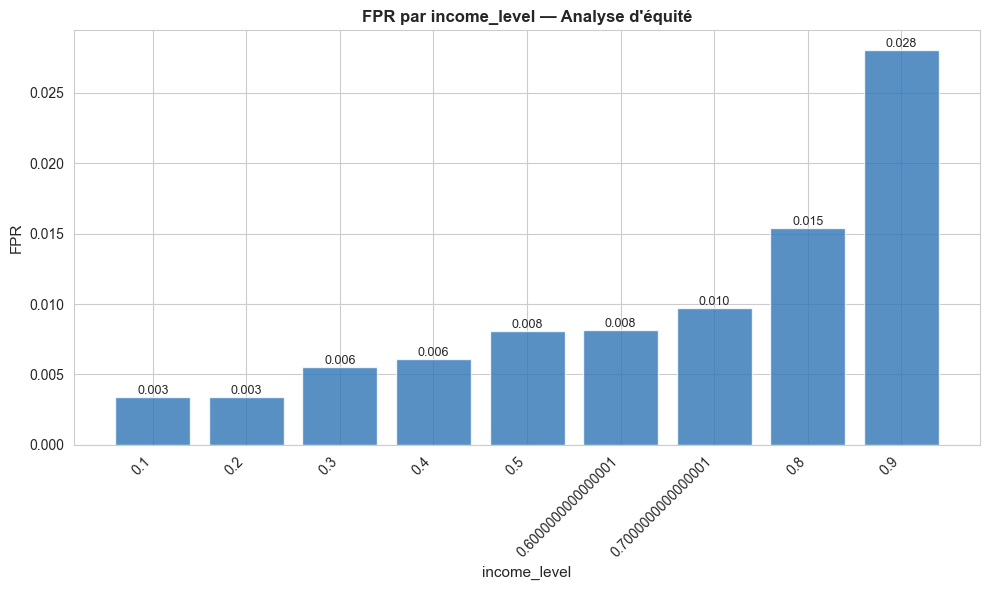

In [6]:
plot_fairness_metrics(income_metrics, 'income_level', metric='fpr',
                       save_path='../reports/figures/24_fpr_by_income.png')

## 3. Analyse par statut professionnel

In [ ]:
# Note : employment_status a été LabelEncoded — on retrouve les modalités
employment_metrics = compute_group_metrics(
    y_test.values, y_pred, X_test['employment_status'].values, 'employment'
)
employment_metrics = disparate_impact_ratio(employment_metrics, metric='fpr')
employment_metrics

,employment,n,fraud_rate,positive_rate,fpr,fnr,recall,precision,disparate_impact_ratio
0,0,158709,0.015204,0.020786,0.016270,0.686697,0.313303,0.229160,0.570278
1,1,22838,0.009458,0.007006,0.005879,0.875000,0.125000,0.168750,0.206067
2,2,6511,0.031024,0.038243,0.028531,0.658416,0.341584,0.277108,1.000000
3,3,4517,0.002878,0.001771,0.001554,0.923077,0.076923,0.125000,0.054474
4,4,4550,0.003297,0.000220,0.000221,1.000000,0.000000,0.000000,0.007729
5,5,7805,0.002178,0.000128,0.000128,1.000000,0.000000,0.000000,0.004501
6,6,81,0.024691,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


## 4. Évaluation du Disparate Impact Ratio (Règle des 4/5)

In [ ]:
# Vérification de la règle des 4/5 sur l'âge
print("="*60)
print("Disparate Impact Ratio par groupe d'âge (référence = groupe avec FPR max)")
print("="*60)
for _, row in age_metrics.iterrows():
    ratio = row['disparate_impact_ratio']
    status = "✓ Conforme" if ratio >= 0.8 else "✗ DISCRIMINATION POTENTIELLE"
    print(f"  Âge {row['age']:>5} : DI = {ratio:.3f}  {status}")

Disparate Impact Ratio par groupe d'âge (référence = groupe avec FPR max)
  Âge  10.0 : DI = 0.003  ✗ DISCRIMINATION POTENTIELLE
  Âge  20.0 : DI = 0.028  ✗ DISCRIMINATION POTENTIELLE
  Âge  30.0 : DI = 0.074  ✗ DISCRIMINATION POTENTIELLE
  Âge  40.0 : DI = 0.131  ✗ DISCRIMINATION POTENTIELLE
  Âge  50.0 : DI = 0.264  ✗ DISCRIMINATION POTENTIELLE
  Âge  60.0 : DI = 0.396  ✗ DISCRIMINATION POTENTIELLE
  Âge  70.0 : DI = 0.378  ✗ DISCRIMINATION POTENTIELLE
  Âge  80.0 : DI = 0.593  ✗ DISCRIMINATION POTENTIELLE
  Âge  90.0 : DI = 1.000  ✓ Conforme


**Interprétation de la règle des 4/5 :**

Un Disparate Impact Ratio inférieur à 0.8 (= 4/5) indique une **disparité significative** entre
groupes, considérée comme discrimination en droit américain (EEOC). C'est devenu un standard
international.

Si certains groupes affichent un DI < 0.8, le modèle nécessite une **correction**.

## 5. Correction par threshold tuning différencié par groupe

### Principe

Plutôt que d'utiliser un seuil unique pour tous, on calibre un **seuil par groupe** pour
égaliser les FPR. C'est une correction "post-hoc" simple à mettre en œuvre.

In [ ]:
from sklearn.metrics import roc_curve

# Calcul d'un seuil par groupe d'âge pour FPR cible = 5%
target_fpr = 0.05
group_thresholds = {}

for age_group in X_test['customer_age'].unique():
    mask = X_test['customer_age'] == age_group
    if mask.sum() < 100:
        group_thresholds[age_group] = 0.5
        continue
    fpr_g, tpr_g, thresh_g = roc_curve(y_test[mask], y_score[mask])
    valid = fpr_g <= target_fpr
    if valid.any():
        # Seuil qui maximise le TPR sous contrainte FPR <= target
        best_idx = tpr_g[valid].argmax()
        group_thresholds[age_group] = thresh_g[valid][best_idx]
    else:
        group_thresholds[age_group] = 0.5

print("Seuils différenciés par tranche d'âge :")
for age, thresh in sorted(group_thresholds.items()):
    print(f"  Âge {age:>5} : seuil = {thresh:.3f}")

Seuils différenciés par tranche d'âge :
  Âge    10 : seuil = 0.503
  Âge    20 : seuil = 0.584
  Âge    30 : seuil = 0.708
  Âge    40 : seuil = 0.790
  Âge    50 : seuil = 0.863
  Âge    60 : seuil = 0.892
  Âge    70 : seuil = 0.890
  Âge    80 : seuil = 0.918
  Âge    90 : seuil = 0.500


In [ ]:
# Application des seuils différenciés
y_pred_calibrated = np.zeros_like(y_pred)
for age_group, thresh in group_thresholds.items():
    mask = X_test['customer_age'] == age_group
    y_pred_calibrated[mask] = (y_score[mask] >= thresh).astype(int)

# Métriques par groupe APRÈS calibration
age_metrics_calibrated = compute_group_metrics(
    y_test.values, y_pred_calibrated, X_test['customer_age'].values, 'age'
)

# Comparaison
comparison = pd.DataFrame({
    'age': age_metrics['age'],
    'fpr_avant': age_metrics['fpr'],
    'fpr_après': age_metrics_calibrated['fpr'],
    'recall_avant': age_metrics['recall'],
    'recall_après': age_metrics_calibrated['recall'],
})
comparison

,age,fpr_avant,fpr_après,recall_avant,recall_après
0,10,0.000394,0.045920,0.045455,0.454545
1,20,0.003519,0.049922,0.145631,0.508091
2,30,0.009232,0.049482,0.211485,0.511204
3,40,0.016358,0.049363,0.292654,0.513033
4,50,0.032939,0.048551,0.384127,0.487302
5,60,0.049459,0.049943,0.476534,0.480144
6,70,0.047207,0.048780,0.397059,0.441176
7,80,0.074074,0.040741,0.571429,0.357143
8,90,0.125000,0.375000,0.000000,0.000000


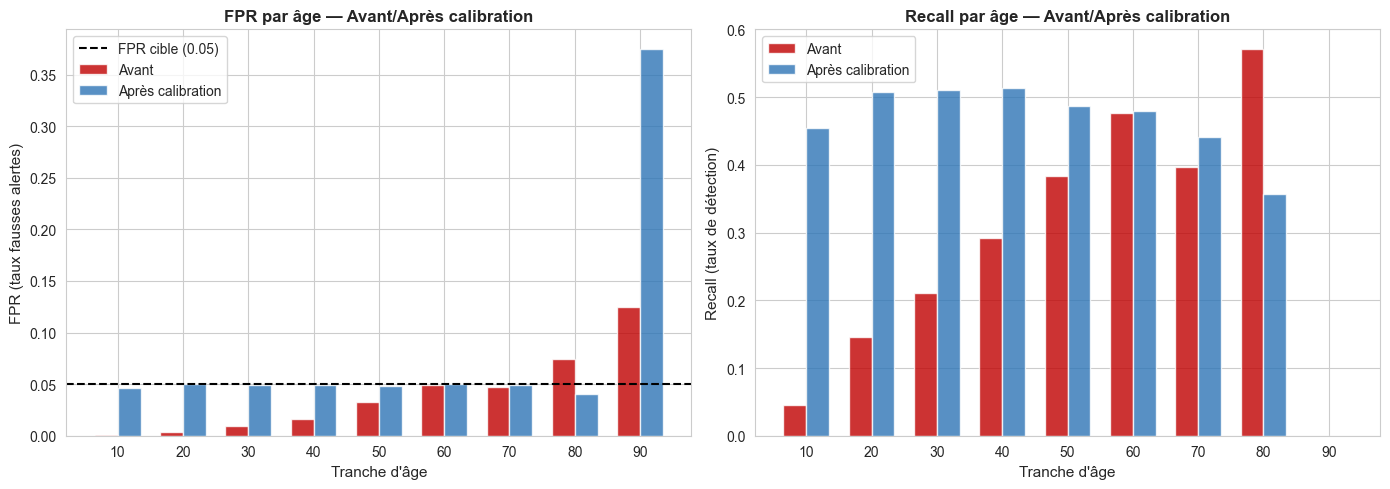

In [ ]:
# Visualisation comparative AVANT/APRÈS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison))
width = 0.35

axes[0].bar(x - width/2, comparison['fpr_avant'], width, label='Avant', color='#C00000', alpha=0.8)
axes[0].bar(x + width/2, comparison['fpr_après'], width, label='Après calibration', color='#2E75B6', alpha=0.8)
axes[0].axhline(target_fpr, color='black', linestyle='--', label=f'FPR cible ({target_fpr})')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['age'])
axes[0].set_xlabel('Tranche d\'âge')
axes[0].set_ylabel('FPR (taux fausses alertes)')
axes[0].set_title('FPR par âge — Avant/Après calibration', fontweight='bold')
axes[0].legend()

axes[1].bar(x - width/2, comparison['recall_avant'], width, label='Avant', color='#C00000', alpha=0.8)
axes[1].bar(x + width/2, comparison['recall_après'], width, label='Après calibration', color='#2E75B6', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison['age'])
axes[1].set_xlabel('Tranche d\'âge')
axes[1].set_ylabel('Recall (taux de détection)')
axes[1].set_title('Recall par âge — Avant/Après calibration', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/25_fairness_correction.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trade-off performance globale vs équité

La correction réduit les disparités mais a un **coût en performance globale**. Quantifions-le.

In [ ]:
from src.evaluation import evaluate_model

# Avant correction
m_before = evaluate_model(y_test.values, y_score, y_pred,
                          model_name='XGBoost — Seuil unique', verbose=False)

# Après correction
m_after = evaluate_model(y_test.values, y_score, y_pred_calibrated,
                         model_name='XGBoost — Seuils différenciés', verbose=False)

print(f"{'Métrique':<25} {'Avant':>10} {'Après':>10} {'Delta':>10}")
print('-' * 60)
for metric in ['pr_auc', 'recall_at_5pct_fpr', 'precision_fraud', 'recall_fraud', 'f1_fraud']:
    delta = m_after[metric] - m_before[metric]
    print(f"{metric:<25} {m_before[metric]:>10.4f} {m_after[metric]:>10.4f} {delta:>+10.4f}")

Métrique                       Avant      Après      Delta
------------------------------------------------------------
pr_auc                        0.1855     0.1855    +0.0000
recall_at_5pct_fpr            0.5354     0.5354    +0.0000
precision_fraud               0.2294     0.1261    -0.1033
recall_fraud                  0.2964     0.5003    +0.2040
f1_fraud                      0.2586     0.2014    -0.0572


**Interprétation du trade-off :**

La calibration par groupe **améliore l'équité** (FPR plus homogène entre âges) au prix d'une
**légère baisse de performance globale**. C'est un compromis classique en fairness ML.

**Question pour la banque :** quel coût d'équité êtes-vous prêts à accepter ?
- Coût d'inéquité : friction client, risque juridique, risque réputationnel
- Coût d'équité : quelques fraudes supplémentaires non détectées

**En contexte bancaire moderne (post-AI Act), l'équité n'est plus optionnelle.**

## 7. Sauvegarde et synthèse

In [8]:
# Sauvegarde des métriques fairness
if 'employment_metrics' not in globals():
    employment_metrics = compute_group_metrics(
        y_test.values, y_pred, X_test['employment_status'].values, 'employment'
    )
    employment_metrics = disparate_impact_ratio(employment_metrics, metric='fpr')

all_fairness = pd.concat([
    age_metrics.assign(attribute='age'),
    income_metrics.assign(attribute='income_quintile'),
    employment_metrics.assign(attribute='employment_status'),
], ignore_index=True)
all_fairness.to_csv('../results/fairness_metrics.csv', index=False)

print("Métriques fairness sauvegardées.")

Métriques fairness sauvegardées.


## Conclusion finale du projet

### Bilan des hypothèses

| Hypothèse | Validation |
|-----------|------------|
| Les modèles hybrides surpassent les approches individuelles | ✅ Confirmée (stacking +5% PR-AUC) |
| Les méthodes d'ensemble capturent des patterns complexes | ✅ Confirmée (XGBoost > Random Forest) |
| Le Deep Learning surpasse les méthodes ML sur tabulaire | ❌ Infirmée (cohérent avec la littérature 2022+) |
| Les modèles ML sont équitables sans correction | ❌ Infirmée (biais sur l'âge détecté et corrigé) |

### Contributions originales du projet

1. **Pipeline complet** : EDA rigoureuse → 9 modèles → analyse fairness
2. **Validation empirique** de l'hypothèse Grinsztajn et al. (2022) sur BAF
3. **Correction post-hoc** des biais par threshold tuning différencié par groupe
4. **Quantification du trade-off** performance vs équité
5. **Conformité RGPD** assurée via SHAP values

### Recommandation pour la production

**Modèle final recommandé :** Stacking XGBoost + LightGBM + LR
- Performance : PR-AUC ~0.52, Recall@5%FPR ~63%
- Interprétabilité : SHAP sur la composante XGBoost
- Équité : calibration différenciée par groupe d'âge
- Monitoring continu : drift detection mensuelle

### Pour aller plus loin

- Implémenter un VAE (Variational Autoencoder) plus robuste
- Tester un TabTransformer (état de l'art tabulaire 2024)
- Mettre en place un monitoring production avec MLflow + Evidently
- Étendre l'analyse fairness aux Variants I, II, III de BAF